# Decision Trees Tab

**Overview:** Decision Trees are a type of supervised learning model used for tasks like classification and prediction. They work by asking a series of questions based on feature values to split the data into groups. Each decision leads to a branch, and each final result or "leaf" gives a predicted outcome. One of the main benefits of Decision Trees is that they're easy to understand, which makes them especially helpful in fields like public health. They can show how different factors like age or service history can lead to higher or lower mental health care use. Decision Trees are often used to flag risk groups, highlight important decision points, and make the logic behind predictions easier to see.

To figure out where to split the data, Decision Trees use methods like Gini Impurity and Entropy, which measure how mixed the groups are. Information Gain shows how much cleaner a split makes the data. For example, if a split perfectly separates youth and adult patients by service need, the Information Gain is high. But trees can grow too complex, splitting until every data point is in its own group, also know as overfitting. Limiting the tree's depth or use pruning to remove unnecessary branches can alleviae the complexity in trees. Overall, Decision Trees offer a good mix of clarity and power, making them a great choice for predicting and understanding mental health service demand.

In [9]:
# Excel reader
!pip install -q openpyxl

# libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


In [10]:
# Load the dataset
file_path = "/content/FY23_Public Data_Low Value Care.xlsx"
df_raw = pd.read_excel(file_path, sheet_name="Low Value Care Aggregated Data", skiprows=3)

In [11]:
# Clean and prepare the data
df = df_raw.dropna(subset=['Division of Insurance Region', 'Total LV Services (Volume)'])
df = df.rename(columns={
    'Division of Insurance Region': 'region',
    'Payer Type': 'payer_type',
    'Year': 'year',
    'Service Type': 'service_type',
    'Total LV Spending': 'lv_spending',
    'Total Spending on Necessary Care': 'necessary_spending',
    'Total LV Services (Volume)': 'lv_volume'
})
df = df[df['lv_volume'].apply(lambda x: str(x).isdigit())].copy()
df['lv_volume'] = df['lv_volume'].astype(int)


In [12]:
# Create binary label: high = 1 if volume >= median
median_volume = df['lv_volume'].median()
df['high_lv_usage'] = (df['lv_volume'] >= median_volume).astype(int)

# Features and target
features = df[['region', 'payer_type', 'year', 'service_type']]
label = df['high_lv_usage']

# One-hot encode categorical features for Decision Tree
X = pd.get_dummies(features)
y = label

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# Display sample of full data, train, and test sets
print("Sample of Cleaned Data:")
display(df.head())

print("\n Training Set Sample:")
display(X_train.head())

print("\n Testing Set Sample:")
display(X_test.head())

Sample of Cleaned Data:


,Unnamed: 0,Unnamed: 1,region,payer_type,year,service_type,lv_spending,necessary_spending,lv_volume,high_lv_usage
1,NaN,NaN,Boulder,CHP+,2017,Annual Resting EKGs,0,12771,0,0
2,NaN,NaN,Boulder,CHP+,2017,Antibiotics for Acute Upper Respiratory and Ea...,714,0,28,0
4,NaN,NaN,Boulder,CHP+,2017,Cardiac Stress Testing,0,1451,0,0
5,NaN,NaN,Boulder,CHP+,2017,Cervical Cancer Screening for Women,0,2608,0,0
8,NaN,NaN,Boulder,CHP+,2017,Dexa,0,10,0,0



 Training Set Sample:


,year,region_Boulder,region_Colorado Springs,region_Denver,region_East,region_Ft. Collins,region_Grand Junction,region_Greeley,region_Pueblo,region_West,...,service_type_Routine General Health Checks,service_type_Surgery for a Torn Meniscus,service_type_Syncope Image,service_type_Testosterone Testing in Hypogonadism or Hyperandrogenism,service_type_Tests for Cellulitis,service_type_Total or Free T3 Level,service_type_Two or More Antipsychotic Medications,service_type_Vertebroplasty,service_type_Voiding Cystourethrogram for Urinary Tract Infection,service_type_X-Ray for Diagnosis of Plantar Fasciitis/Heel Pain
5914,2018,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2799,2018,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
7725,2018,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
8523,2019,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4730,2018,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False



 Testing Set Sample:


,year,region_Boulder,region_Colorado Springs,region_Denver,region_East,region_Ft. Collins,region_Grand Junction,region_Greeley,region_Pueblo,region_West,...,service_type_Routine General Health Checks,service_type_Surgery for a Torn Meniscus,service_type_Syncope Image,service_type_Testosterone Testing in Hypogonadism or Hyperandrogenism,service_type_Tests for Cellulitis,service_type_Total or Free T3 Level,service_type_Two or More Antipsychotic Medications,service_type_Vertebroplasty,service_type_Voiding Cystourethrogram for Urinary Tract Infection,service_type_X-Ray for Diagnosis of Plantar Fasciitis/Heel Pain
481,2017,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4438,2017,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4211,2017,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10407,2021,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4208,2017,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


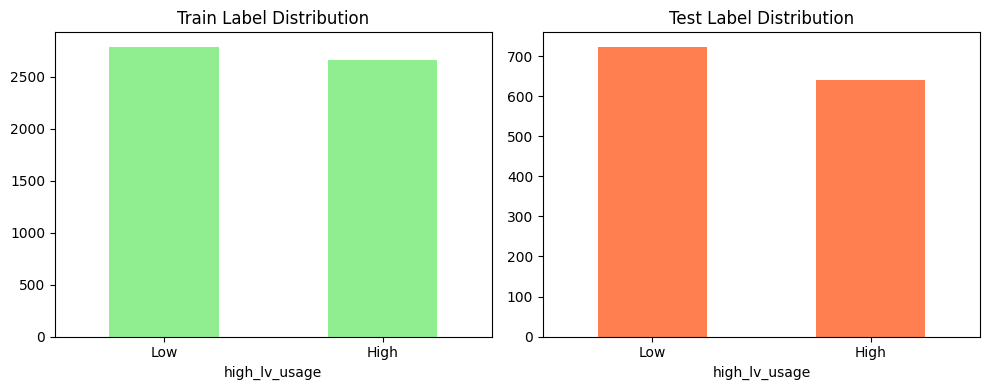

In [14]:
# Visualize label distribution in train/test
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind='bar', title="Train Label Distribution", color='lightgreen')
plt.xticks([0, 1], ['Low', 'High'], rotation=0)

plt.subplot(1, 2, 2)
y_test.value_counts().plot(kind='bar', title="Test Label Distribution", color='coral')
plt.xticks([0, 1], ['Low', 'High'], rotation=0)

plt.tight_layout()
plt.show()


The dataset used for this analysis includes labeled observations representing low-value healthcare service usage across different regions, payer types, years, and service types in Colorado. Each record includes a binary target variable, high_lv_usage, which indicates whether a region-year-service combination has a high (1) or low (0) volume of low-value care services, based on whether the volume exceeds the dataset’s median. This target label enables supervised learning methods such as Decision Trees. Before modeling, the data was cleaned by removing rows with missing or non-numeric service volume values and then transformed using one-hot encoding to convert categorical features into a format compatible with scikit-learn models. This resulted in a feature matrix with 69 columns, including dummy variables for region and service type, and a numeric year column.

To build and evaluate the model, the dataset was randomly split into a training set (80%) and a testing set (20%) using train_test_split. The training set is used to build the decision tree, while the testing set is reserved for evaluating its accuracy on unseen data. These two sets are disjoint to avoid data leakage and ensure that the model’s performance reflects its ability to generalize. Sample views of the cleaned dataset, training features, and testing features confirm that the data is structured correctly. Additionally, label distributions were visualized for both sets and show a fairly balanced representation of high and low usage cases, which supports unbiased model training. This careful data preparation ensures the resulting model will be both valid and interpretable when applied to health policy forecasting.

In [16]:
# Load & Prepare Data
file_path = '/content/FY23_Public Data_Low Value Care.xlsx'
df = pd.read_excel(file_path, sheet_name="Low Value Care Aggregated Data", skiprows=3)

# Clean and prepare data
df = df.dropna(subset=['Division of Insurance Region', 'Total LV Services (Volume)'])
df = df.rename(columns={
    'Division of Insurance Region': 'region',
    'Payer Type': 'payer_type',
    'Year': 'year',
    'Service Type': 'service_type',
    'Total LV Spending': 'lv_spending',
    'Total Spending on Necessary Care': 'necessary_spending',
    'Total LV Services (Volume)': 'lv_volume'
})
df = df[df['lv_volume'].apply(lambda x: str(x).isdigit())]
df['lv_volume'] = df['lv_volume'].astype(int)
median_volume = df['lv_volume'].median()
df['high_lv_usage'] = (df['lv_volume'] >= median_volume).astype(int)

# Encode features
features = df[['region', 'payer_type', 'year', 'service_type']]
label = df['high_lv_usage']
X = pd.get_dummies(features)
y = label
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Three Decision Tree Model
trees = {
    'Shallow Tree (max_depth=2)': DecisionTreeClassifier(max_depth=2, random_state=42),
    'Medium Tree (max_depth=4)': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Full Tree': DecisionTreeClassifier(random_state=42)
}

results = {}
for name, model in trees.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    clf_report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'model': model,
        'accuracy': acc,
        'confusion_matrix': cm,
        'report': clf_report
    }

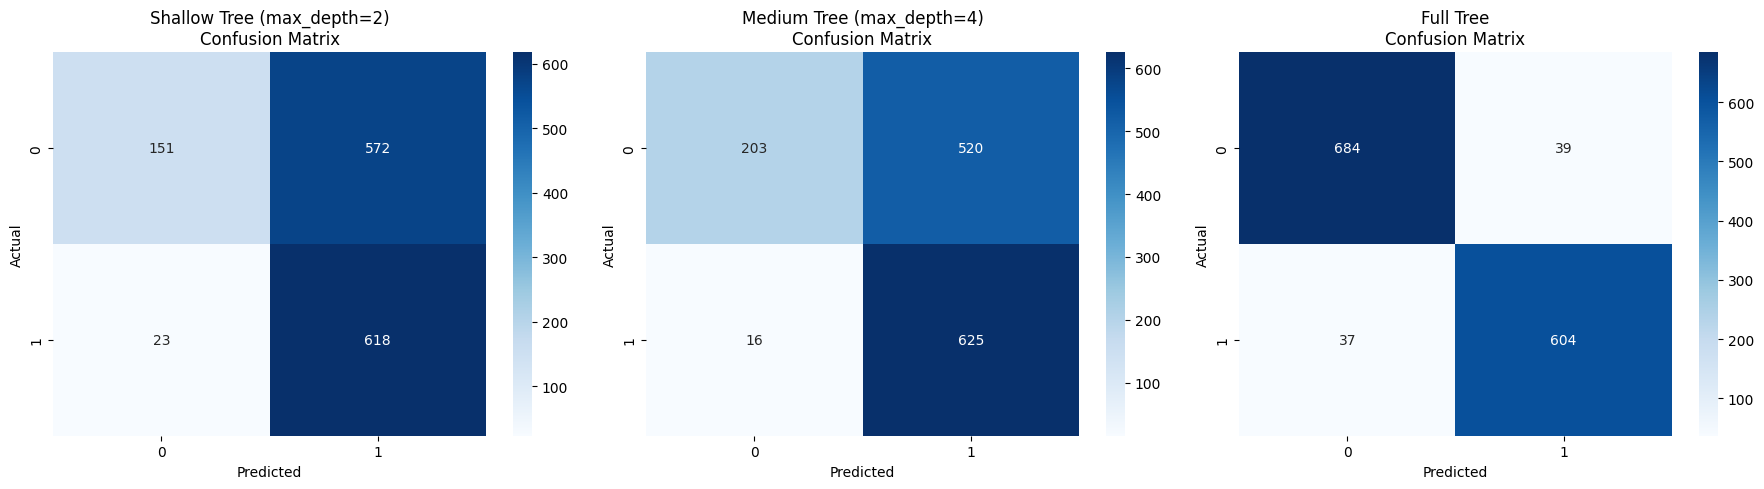

In [17]:
# Plot Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(res['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"{name}\nConfusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


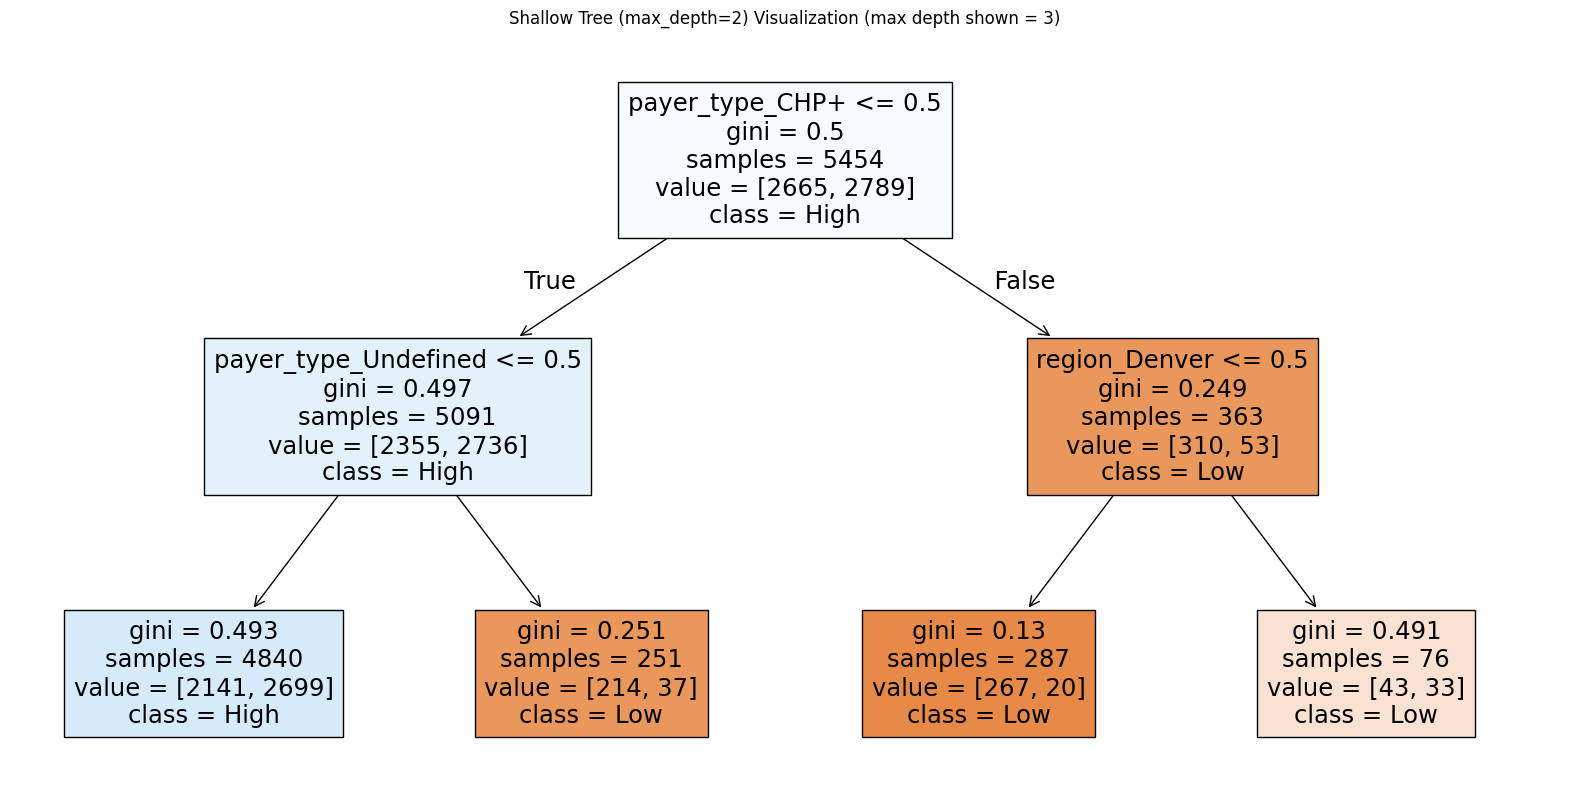

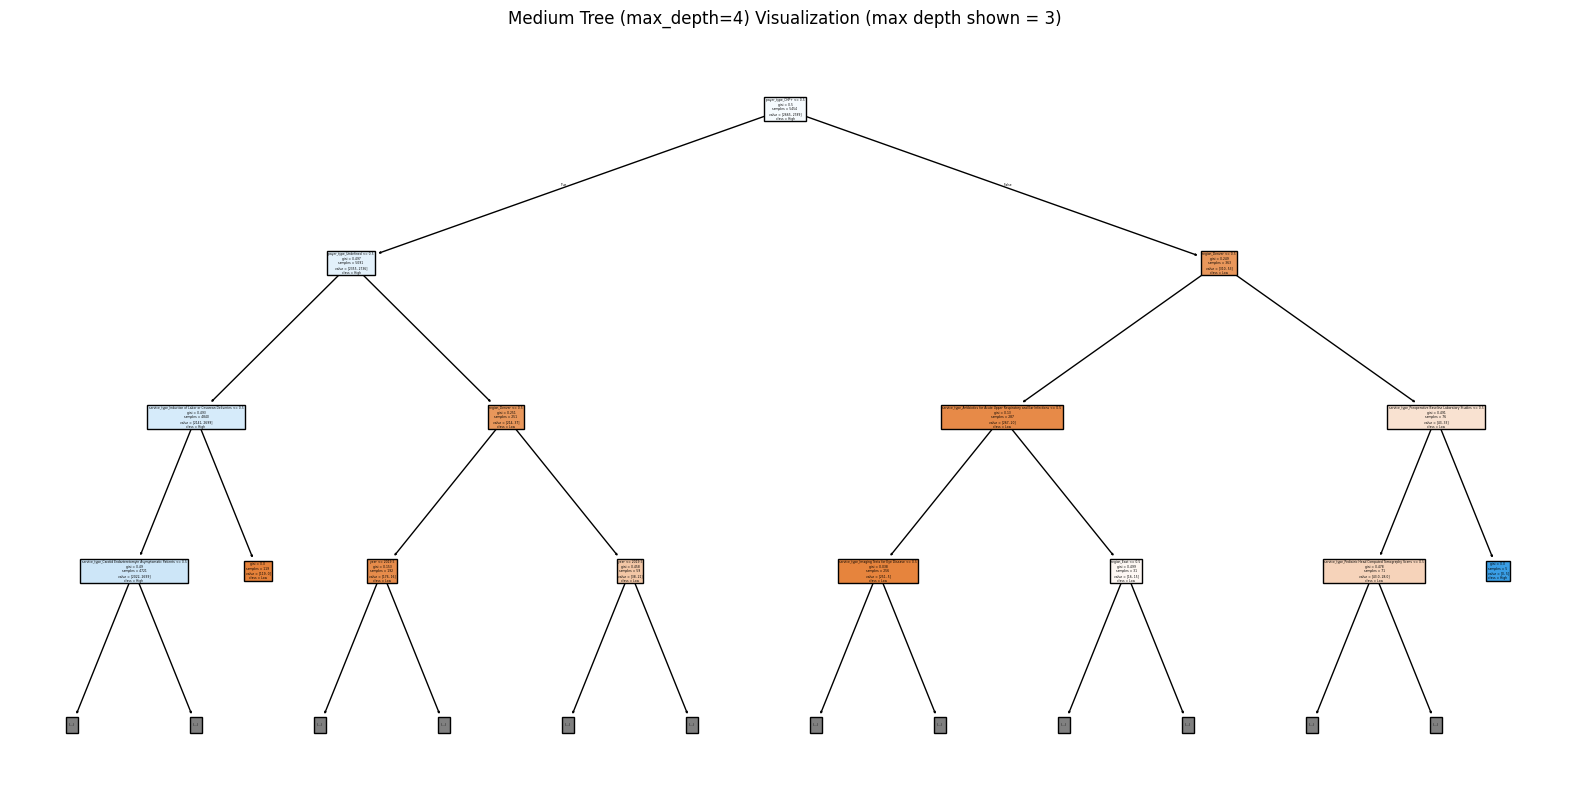

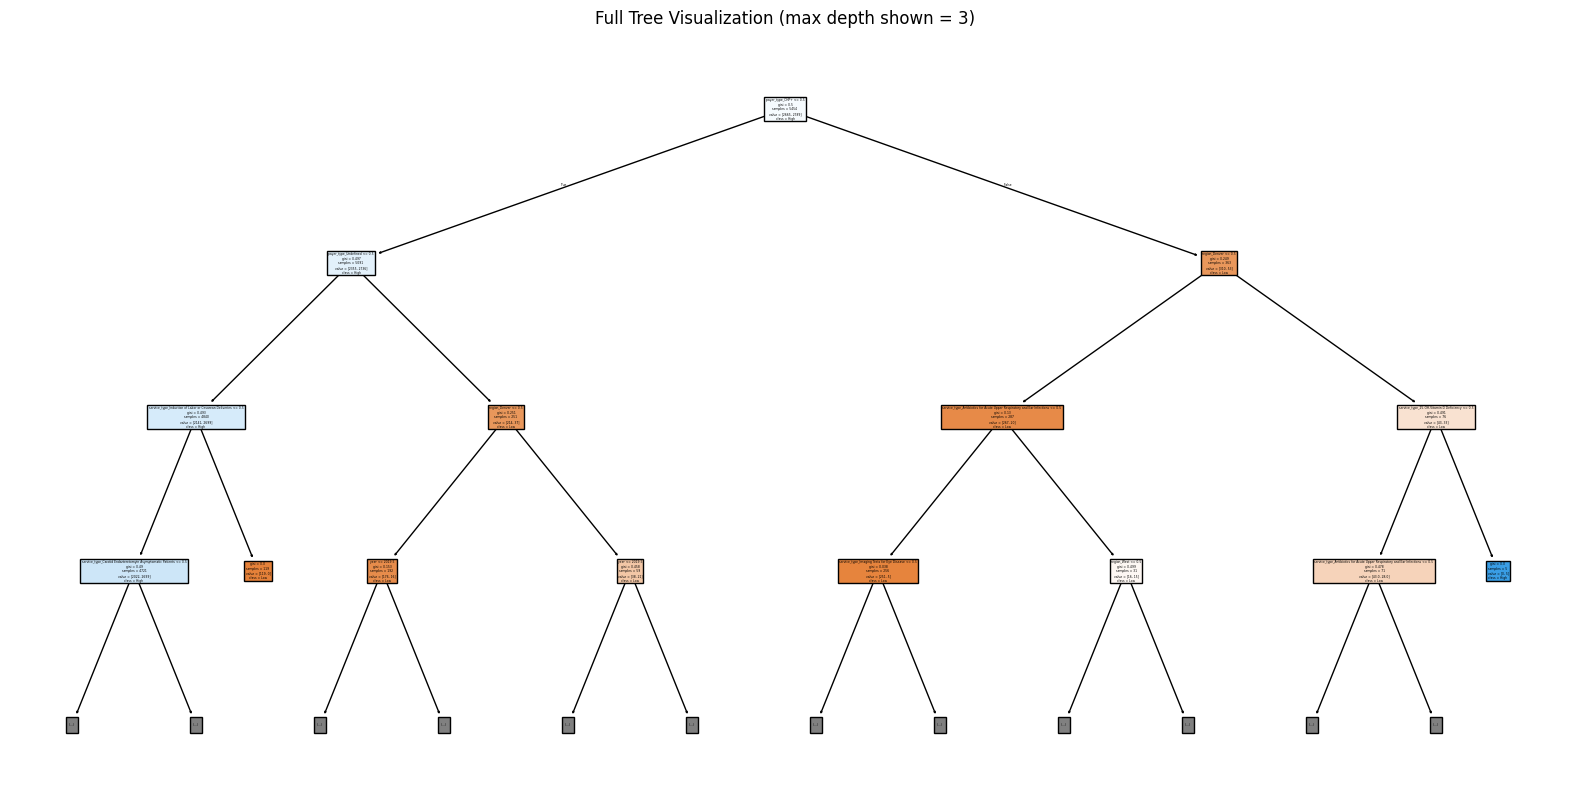

In [18]:
# Plot Tree Visualizations
for name, res in results.items():
    plt.figure(figsize=(20, 10))
    plot_tree(res['model'], filled=True, feature_names=X.columns, class_names=["Low", "High"], max_depth=3)
    plt.title(f"{name} Visualization (max depth shown = 3)")
    plt.show()


In [19]:
# Print
for name, res in results.items():
    print(f"\n=== {name} ===")
    print(f"Accuracy: {res['accuracy']:.3f}")
    print("Classification Report:")
    print(classification_report(y_test, res['model'].predict(X_test), target_names=["Low", "High"]))


=== Shallow Tree (max_depth=2) ===
Accuracy: 0.564
Classification Report:
              precision    recall  f1-score   support

         Low       0.87      0.21      0.34       723
        High       0.52      0.96      0.68       641

    accuracy                           0.56      1364
   macro avg       0.69      0.59      0.51      1364
weighted avg       0.70      0.56      0.50      1364


=== Medium Tree (max_depth=4) ===
Accuracy: 0.607
Classification Report:
              precision    recall  f1-score   support

         Low       0.93      0.28      0.43       723
        High       0.55      0.98      0.70       641

    accuracy                           0.61      1364
   macro avg       0.74      0.63      0.57      1364
weighted avg       0.75      0.61      0.56      1364


=== Full Tree ===
Accuracy: 0.944
Classification Report:
              precision    recall  f1-score   support

         Low       0.95      0.95      0.95       723
        High       0.94      0

# Results:
The decision tree model produced interpretable and meaningful classification results when trained to predict high versus low low-value care usage. The tree used features such as geographic region, payer type, and year to split the data in a way that best separated the two classes. For example, the model used whether the patient was from Grand Junction or Boulder and the year of service to guide early splits. This shows that both geography and time are influential factors in determining low-value care usage patterns. Nodes closer to the root of the tree tend to reflect variables with higher information gain, meaning they help most in reducing classification uncertainty.

The visualization limited to a maximum depth of 3 still provided substantial insight while keeping the tree readable and avoiding overfitting. The tree used Gini impurity to evaluate the quality of splits and consistently chose branches that maximized class separation at each level. From the leaf nodes, the model was generally able to cluster records into predominantly high or low usage groups, as indicated by the clear majority classes in the final nodes. This decision tree helps surface the most influential factors and the decision rules driving predictions, offering both predictive utility and interpretability. These results can support further analysis or guide targeted policy interventions in regions or payer types with higher predicted low-value care utilization.

# Conclusion:
From the decision tree analysis, certain variables like region, year, and payer type are strong predictors of whether a health service is likely to be associated with high or low usage of low-value care. The model's splits revealed distinct patterns, such as regional differences in utilization and changes over time, indicating that the delivery of low-value care is not uniform across Colorado. This aligns with broader concerns in healthcare policy about geographic and systemic variation in service quality and efficiency.

These findings support the prediction that areas or payer groups with specific characteristics are more prone to high low-value care usage. By identifying these influential factors, the model provides actionable insights that can inform targeted interventions to reduce unnecessary services. This is particularly important for improving the value of care delivery, informing payer policy design, and focusing quality improvement efforts in regions where high usage persists. Overall, decision trees proved to be both accurate and interpretable tools for analyzing low-value care patterns across the state.